In [57]:
import pandas as pd
import numpy as np
import os
print("Notebook is working")
file_path = "../data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
print(os.path.exists(file_path))

Notebook is working
True


In [58]:

df = pd.read_csv(file_path)
print(df.shape)
df.head()

(170366, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [59]:
df.columns.tolist()

[' Destination Port',
 ' Flow Duration',
 ' Total Fwd Packets',
 ' Total Backward Packets',
 'Total Length of Fwd Packets',
 ' Total Length of Bwd Packets',
 ' Fwd Packet Length Max',
 ' Fwd Packet Length Min',
 ' Fwd Packet Length Mean',
 ' Fwd Packet Length Std',
 'Bwd Packet Length Max',
 ' Bwd Packet Length Min',
 ' Bwd Packet Length Mean',
 ' Bwd Packet Length Std',
 'Flow Bytes/s',
 ' Flow Packets/s',
 ' Flow IAT Mean',
 ' Flow IAT Std',
 ' Flow IAT Max',
 ' Flow IAT Min',
 'Fwd IAT Total',
 ' Fwd IAT Mean',
 ' Fwd IAT Std',
 ' Fwd IAT Max',
 ' Fwd IAT Min',
 'Bwd IAT Total',
 ' Bwd IAT Mean',
 ' Bwd IAT Std',
 ' Bwd IAT Max',
 ' Bwd IAT Min',
 'Fwd PSH Flags',
 ' Bwd PSH Flags',
 ' Fwd URG Flags',
 ' Bwd URG Flags',
 ' Fwd Header Length',
 ' Bwd Header Length',
 'Fwd Packets/s',
 ' Bwd Packets/s',
 ' Min Packet Length',
 ' Max Packet Length',
 ' Packet Length Mean',
 ' Packet Length Std',
 ' Packet Length Variance',
 'FIN Flag Count',
 ' SYN Flag Count',
 ' RST Flag Count',
 ' P

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170366 entries, 0 to 170365
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             170366 non-null  int64  
 1    Flow Duration                170366 non-null  int64  
 2    Total Fwd Packets            170366 non-null  int64  
 3    Total Backward Packets       170366 non-null  int64  
 4   Total Length of Fwd Packets   170366 non-null  int64  
 5    Total Length of Bwd Packets  170366 non-null  int64  
 6    Fwd Packet Length Max        170366 non-null  int64  
 7    Fwd Packet Length Min        170366 non-null  int64  
 8    Fwd Packet Length Mean       170366 non-null  float64
 9    Fwd Packet Length Std        170366 non-null  float64
 10  Bwd Packet Length Max         170366 non-null  int64  
 11   Bwd Packet Length Min        170366 non-null  int64  
 12   Bwd Packet Length Mean       170366 non-null  float64


In [61]:
df.isnull().sum().sort_values(ascending=False).head(20)

Flow Bytes/s               20
 Destination Port           0
 Bwd Avg Bytes/Bulk         0
 Fwd Avg Packets/Bulk       0
Fwd Avg Bytes/Bulk          0
 Fwd Header Length.1        0
 Avg Bwd Segment Size       0
 Avg Fwd Segment Size       0
 Average Packet Size        0
 Down/Up Ratio              0
 ECE Flag Count             0
 CWE Flag Count             0
 URG Flag Count             0
 ACK Flag Count             0
 PSH Flag Count             0
 RST Flag Count             0
 SYN Flag Count             0
FIN Flag Count              0
 Packet Length Variance     0
 Fwd Avg Bulk Rate          0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(6066)

In [63]:
[c for c in df.columns if "label" in c.lower()]

[' Label']

In [64]:
df.columns = df.columns.str.strip()
df["Label"].dtype
df["Label"].value_counts()


Label
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

In [65]:
df_clean = df.copy()

# remove duplicate rows
df_clean = df_clean.drop_duplicates()

# remove rows with missing values
df_clean = df_clean.dropna()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Duplicates after cleaning:", df_clean.duplicated().sum())
print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Original shape: (170366, 79)
Cleaned shape: (164281, 79)
Duplicates after cleaning: 0
Missing values after cleaning: 0


In [66]:
df_clean["Label"].value_counts()

Label
BENIGN                        162138
Web Attack � Brute Force        1470
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

In [67]:
df_clean["Label_Binary"] = (df_clean["Label"] != "BENIGN").astype(int)
df_clean["Label_Binary"].value_counts()

Label_Binary
0    162138
1      2143
Name: count, dtype: int64

In [68]:
output_path = "../data/processed/cleaned_web_attacks.csv"
df_clean.to_csv(output_path, index=False)
print("Saved to:", output_path)

Saved to: ../data/processed/cleaned_web_attacks.csv


In [69]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Duplicates after cleaning:", df_clean.duplicated().sum())
print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Original shape: (170366, 79)
Cleaned shape: (164281, 79)
Duplicates after cleaning: 0
Missing values after cleaning: 0


In [70]:
output_path = "../data/processed/cleaned_web_attacks.csv"
df_clean.to_csv(output_path, index=False)
print("Saved to:", output_path)

Saved to: ../data/processed/cleaned_web_attacks.csv


In [71]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Duplicates after cleaning:", df_clean.duplicated().sum())
print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Original shape: (170366, 79)
Cleaned shape: (164281, 79)
Duplicates after cleaning: 0
Missing values after cleaning: 0


In [72]:
df_clean["Label"].value_counts()

Label
BENIGN                        162138
Web Attack � Brute Force        1470
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

In [73]:
df_clean["Label_Binary"] = (df_clean["Label"] != "BENIGN").astype(int)
df_clean["Label_Binary"].value_counts()

Label_Binary
0    162138
1      2143
Name: count, dtype: int64

In [74]:
output_path = "../data/processed/cleaned_web_attacks.csv"
df_clean.to_csv(output_path, index=False)
print("Saved to:", output_path)

Saved to: ../data/processed/cleaned_web_attacks.csv


In [75]:
X = df_clean.drop(columns=["Label", "Label_Binary"])
y = df_clean["Label_Binary"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (164281, 78)
y shape: (164281,)


In [76]:
X.dtypes.value_counts()

int64      54
float64    24
Name: count, dtype: int64

In [77]:
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
non_numeric_cols

[]

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (131424, 78)
X_test shape: (32857, 78)
y_train shape: (131424,)
y_test shape: (32857,)


In [79]:
print("Training label counts:")
print(y_train.value_counts())

print("\nTesting label counts:")
print(y_test.value_counts())

Training label counts:
Label_Binary
0    129710
1      1714
Name: count, dtype: int64

Testing label counts:
Label_Binary
0    32428
1      429
Name: count, dtype: int64


In [80]:
import numpy as np

print("Infinite values in X_train:", np.isinf(X_train.select_dtypes(include=["number"])).sum().sum())
print("Infinite values in X_test:", np.isinf(X_test.select_dtypes(include=["number"])).sum().sum())

Infinite values in X_train: 158
Infinite values in X_test: 46


In [81]:
X = df_clean.drop(columns=["Label", "Label_Binary"])
y = df_clean["Label_Binary"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (164281, 78)
y shape: (164281,)


In [82]:
X.dtypes.value_counts()

int64      54
float64    24
Name: count, dtype: int64

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (131424, 78)
X_test shape: (32857, 78)
y_train shape: (131424,)
y_test shape: (32857,)


In [84]:
print("Training label counts:")
print(y_train.value_counts())

print("\nTesting label counts:")
print(y_test.value_counts())

Training label counts:
Label_Binary
0    129710
1      1714
Name: count, dtype: int64

Testing label counts:
Label_Binary
0    32428
1      429
Name: count, dtype: int64


In [85]:
import numpy as np

print("Infinite values in X_train:", np.isinf(X_train.select_dtypes(include=["number"])).sum().sum())
print("Infinite values in X_test:", np.isinf(X_test.select_dtypes(include=["number"])).sum().sum())

Infinite values in X_train: 158
Infinite values in X_test: 46


In [86]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

print("Infinite values in X_train after replacement:", np.isinf(X_train.select_dtypes(include=["number"])).sum().sum())
print("Infinite values in X_test after replacement:", np.isinf(X_test.select_dtypes(include=["number"])).sum().sum())

print("Missing values in X_train after replacement:", X_train.isnull().sum().sum())
print("Missing values in X_test after replacement:", X_test.isnull().sum().sum())

Infinite values in X_train after replacement: 0
Infinite values in X_test after replacement: 0
Missing values in X_train after replacement: 158
Missing values in X_test after replacement: 46


In [87]:
train_medians = X_train.median(numeric_only=True)

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Missing values in X_train after fill:", X_train.isnull().sum().sum())
print("Missing values in X_test after fill:", X_test.isnull().sum().sum())

Missing values in X_train after fill: 0
Missing values in X_test after fill: 0


In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (131424, 78)
Scaled test shape: (32857, 78)


In [89]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [90]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9799738259731564
Precision: 0.3938832252085264
Recall: 0.9906759906759907
F1-score: 0.5636604774535809

Confusion Matrix:
[[31774   654]
 [    4   425]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     32428
           1       0.39      0.99      0.56       429

    accuracy                           0.98     32857
   macro avg       0.70      0.99      0.78     32857
weighted avg       0.99      0.98      0.98     32857



In [91]:
from sklearn.metrics import roc_auc_score

y_scores = log_reg.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_scores))

ROC-AUC: 0.9973072135709363


In [92]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

print("Infinite values in X_train after replacement:", np.isinf(X_train.select_dtypes(include=["number"])).sum().sum())
print("Infinite values in X_test after replacement:", np.isinf(X_test.select_dtypes(include=["number"])).sum().sum())

print("Missing values in X_train after replacement:", X_train.isnull().sum().sum())
print("Missing values in X_test after replacement:", X_test.isnull().sum().sum())

Infinite values in X_train after replacement: 0
Infinite values in X_test after replacement: 0
Missing values in X_train after replacement: 0
Missing values in X_test after replacement: 0


In [93]:
train_medians = X_train.median(numeric_only=True)

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Missing values in X_train after fill:", X_train.isnull().sum().sum())
print("Missing values in X_test after fill:", X_test.isnull().sum().sum())

Missing values in X_train after fill: 0
Missing values in X_test after fill: 0


In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (131424, 78)
Scaled test shape: (32857, 78)


In [95]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9799738259731564
Precision: 0.3938832252085264
Recall: 0.9906759906759907
F1-score: 0.5636604774535809

Confusion Matrix:
[[31774   654]
 [    4   425]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     32428
           1       0.39      0.99      0.56       429

    accuracy                           0.98     32857
   macro avg       0.70      0.99      0.78     32857
weighted avg       0.99      0.98      0.98     32857



In [96]:
from sklearn.metrics import roc_auc_score

y_scores = log_reg.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_scores))

ROC-AUC: 0.9973072135709363


In [97]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [98]:
import pandas as pd

results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.9799738259731564,
        "Precision": 0.3938832252085264,
        "Recall": 0.9906759906759907,
        "F1": 0.5636604774535809,
        "ROC-AUC": 0.9973072135709363
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.9997869555954592,
        "Precision": 0.9953051643192489,
        "Recall": 0.9883449883449883,
        "F1": 0.991812865497076,
        "ROC-AUC": 0.9999904755825565
    }
])

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.979974,0.393883,0.990676,0.563660,0.997307
1,Random Forest,0.999787,0.995305,0.988345,0.991813,0.999990


In [99]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

feature_importances.head(15)

Init_Win_bytes_backward        0.106603
Fwd IAT Min                    0.079016
Max Packet Length              0.076890
Average Packet Size            0.057587
Init_Win_bytes_forward         0.056908
Fwd Packet Length Mean         0.054671
Destination Port               0.047453
Total Length of Fwd Packets    0.040731
Flow IAT Max                   0.034879
Flow Packets/s                 0.034089
Avg Fwd Segment Size           0.029330
Subflow Fwd Bytes              0.028540
Packet Length Mean             0.027345
Flow IAT Mean                  0.025075
Flow Bytes/s                   0.019695
dtype: float64

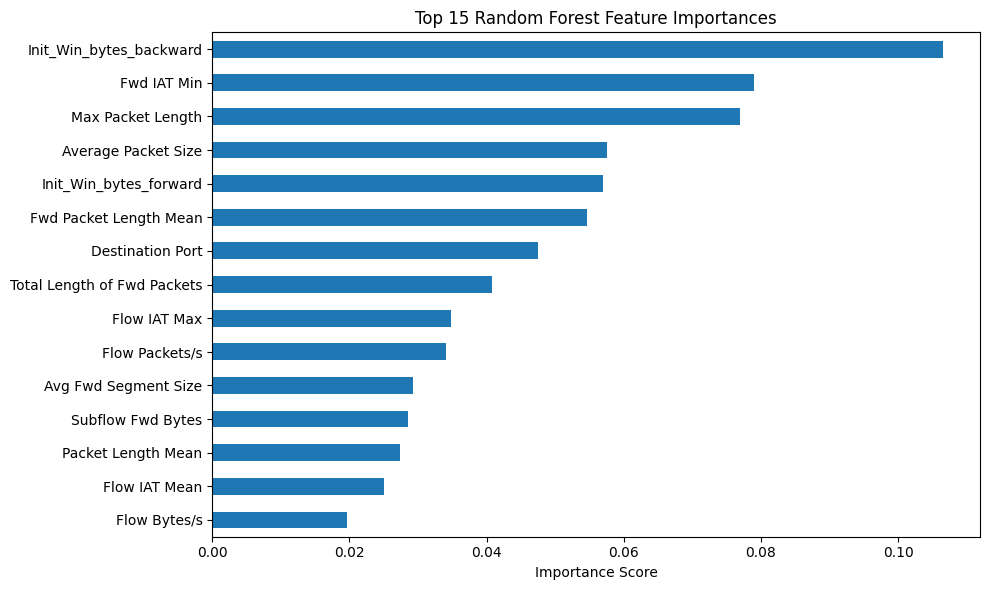

In [100]:
import matplotlib.pyplot as plt

top_features = feature_importances.head(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [101]:
top_15_features = feature_importances.head(15).index.tolist()
top_15_features

['Init_Win_bytes_backward',
 'Fwd IAT Min',
 'Max Packet Length',
 'Average Packet Size',
 'Init_Win_bytes_forward',
 'Fwd Packet Length Mean',
 'Destination Port',
 'Total Length of Fwd Packets',
 'Flow IAT Max',
 'Flow Packets/s',
 'Avg Fwd Segment Size',
 'Subflow Fwd Bytes',
 'Packet Length Mean',
 'Flow IAT Mean',
 'Flow Bytes/s']

In [102]:
X_train_top = X_train[top_15_features].copy()
X_test_top = X_test[top_15_features].copy()

print("X_train_top shape:", X_train_top.shape)
print("X_test_top shape:", X_test_top.shape)

X_train_top shape: (131424, 15)
X_test_top shape: (32857, 15)


In [103]:
from sklearn.preprocessing import StandardScaler

lstm_scaler = StandardScaler()

X_train_top_scaled = lstm_scaler.fit_transform(X_train_top)
X_test_top_scaled = lstm_scaler.transform(X_test_top)

print(X_train_top_scaled.shape)
print(X_test_top_scaled.shape)

(131424, 15)
(32857, 15)


In [104]:
import numpy as np

def create_sequences(X, y, seq_length=10):
    X_seq = []
    y_seq = []
    
    for i in range(len(X) - seq_length + 1):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y.iloc[i + seq_length - 1])
    
    return np.array(X_seq), np.array(y_seq)

seq_length = 10

X_train_seq, y_train_seq = create_sequences(
    X_train_top_scaled, y_train.reset_index(drop=True), seq_length
)

X_test_seq, y_test_seq = create_sequences(
    X_test_top_scaled, y_test.reset_index(drop=True), seq_length
)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (131415, 10, 15)
y_train_seq shape: (131415,)
X_test_seq shape: (32848, 10, 15)
y_test_seq shape: (32848,)


In [105]:
print("Training sequence labels:")
print(pd.Series(y_train_seq).value_counts())

print("\nTesting sequence labels:")
print(pd.Series(y_test_seq).value_counts())

Training sequence labels:
0    129701
1      1714
Name: count, dtype: int64

Testing sequence labels:
0    32420
1      428
Name: count, dtype: int64


In [106]:
top_15_features = feature_importances.head(15).index.tolist()
top_15_features

['Init_Win_bytes_backward',
 'Fwd IAT Min',
 'Max Packet Length',
 'Average Packet Size',
 'Init_Win_bytes_forward',
 'Fwd Packet Length Mean',
 'Destination Port',
 'Total Length of Fwd Packets',
 'Flow IAT Max',
 'Flow Packets/s',
 'Avg Fwd Segment Size',
 'Subflow Fwd Bytes',
 'Packet Length Mean',
 'Flow IAT Mean',
 'Flow Bytes/s']

In [107]:
X_train_top = X_train[top_15_features].copy()
X_test_top = X_test[top_15_features].copy()

print("X_train_top shape:", X_train_top.shape)
print("X_test_top shape:", X_test_top.shape)

X_train_top shape: (131424, 15)
X_test_top shape: (32857, 15)


In [108]:
from sklearn.preprocessing import StandardScaler

lstm_scaler = StandardScaler()

X_train_top_scaled = lstm_scaler.fit_transform(X_train_top)
X_test_top_scaled = lstm_scaler.transform(X_test_top)

print(X_train_top_scaled.shape)
print(X_test_top_scaled.shape)

(131424, 15)
(32857, 15)


In [109]:
import numpy as np

def create_sequences(X, y, seq_length=10):
    X_seq = []
    y_seq = []
    
    for i in range(len(X) - seq_length + 1):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y.iloc[i + seq_length - 1])
    
    return np.array(X_seq), np.array(y_seq)

seq_length = 10

X_train_seq, y_train_seq = create_sequences(
    X_train_top_scaled, y_train.reset_index(drop=True), seq_length
)

X_test_seq, y_test_seq = create_sequences(
    X_test_top_scaled, y_test.reset_index(drop=True), seq_length
)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (131415, 10, 15)
y_train_seq shape: (131415,)
X_test_seq shape: (32848, 10, 15)
y_test_seq shape: (32848,)


In [110]:
print("Training sequence labels:")
print(pd.Series(y_train_seq).value_counts())

print("\nTesting sequence labels:")
print(pd.Series(y_test_seq).value_counts())

Training sequence labels:
0    129701
1      1714
Name: count, dtype: int64

Testing sequence labels:
0    32420
1      428
Name: count, dtype: int64
